In [157]:
%load_ext autoreload
%autoreload 2

import numpy as np, sys, os, pathlib

REPO_DIR = pathlib.Path(os.path.dirname(os.path.abspath(os.getcwd()))); print(REPO_DIR)
sys.path.insert(0, str(REPO_DIR / "src"))

from traffic_sim import run_metanet_sim_plottable
from viz import Plotter

# Both me and monica load from same file
# Look at ways to fix numerical issues - bound by small epsilon (add to denominator)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/tristanchaang/MIT/UROP-Traffic/mpc-traffic-flow


In [ ]:
def smooth_inflow(inflow: np.ndarray, window_size: int = 2) -> np.ndarray:
    from scipy.ndimage import uniform_filter1d
    return uniform_filter1d(inflow, window_size, axis=0, mode="nearest", output=np.float64)

## Data and Calibration loading

In [159]:
# Define parameters for METANET Model
L = 0.4 # miles
time_step = 10/3600 # hours
total_time = 1 # hours
start_time = 0 # hours
start_time_step = int(start_time / time_step)

In [293]:
from paths import DEFAULT_CALIBRATION, ensure_dir

# Read in the data
DATE = "11_30"
CONSTRAINT = "" # or "speed_lb", "hold_length", "safety_sweep"
SPEED_LBS = [0]
assert(CONSTRAINT == "" or SPEED_LBS == [0])

calibration_id = DEFAULT_CALIBRATION # default: "calibration_static/fixed_ramping"
calibration_interval = None            # None if static, else interval in time steps
calibration_folder = f"control_h_{calibration_interval}" if calibration_interval else ""

data_path    = REPO_DIR / "data" / "i24" / f"i24_{DATE}"
cal_path     = data_path / calibration_id / calibration_folder
results_path = REPO_DIR / "results" / "i24" / f"i24_{DATE}" / calibration_id / calibration_folder / CONSTRAINT
results_path = ensure_dir(results_path)

# Assert data exists
assert os.path.exists(cal_path), f"Calibration parameters not found at {cal_path}"
assert all(os.path.exists(data_path/f'{f}.npy') for f in ['v_hat', 'rho_hat']), f"Data not found at {data_path}"

print("data_path:\t", str(data_path))
print("cal_path:\t", str(cal_path))
print("results_path:\t", str(results_path))

data_path:	 /Users/tristanchaang/MIT/UROP-Traffic/mpc-traffic-flow/data/i24/i24_11_30
cal_path:	 /Users/tristanchaang/MIT/UROP-Traffic/mpc-traffic-flow/data/i24/i24_11_30/calibration_static/fixed_ramping
results_path:	 /Users/tristanchaang/MIT/UROP-Traffic/mpc-traffic-flow/results/i24/i24_11_30/calibration_static/fixed_ramping


### Real data loading

time_step:		 10.0 seconds
time_steps:		 360
num_segments:		 14
sim_time:		 60.0 minutes
length of highway:	 5.6000000000000005 km


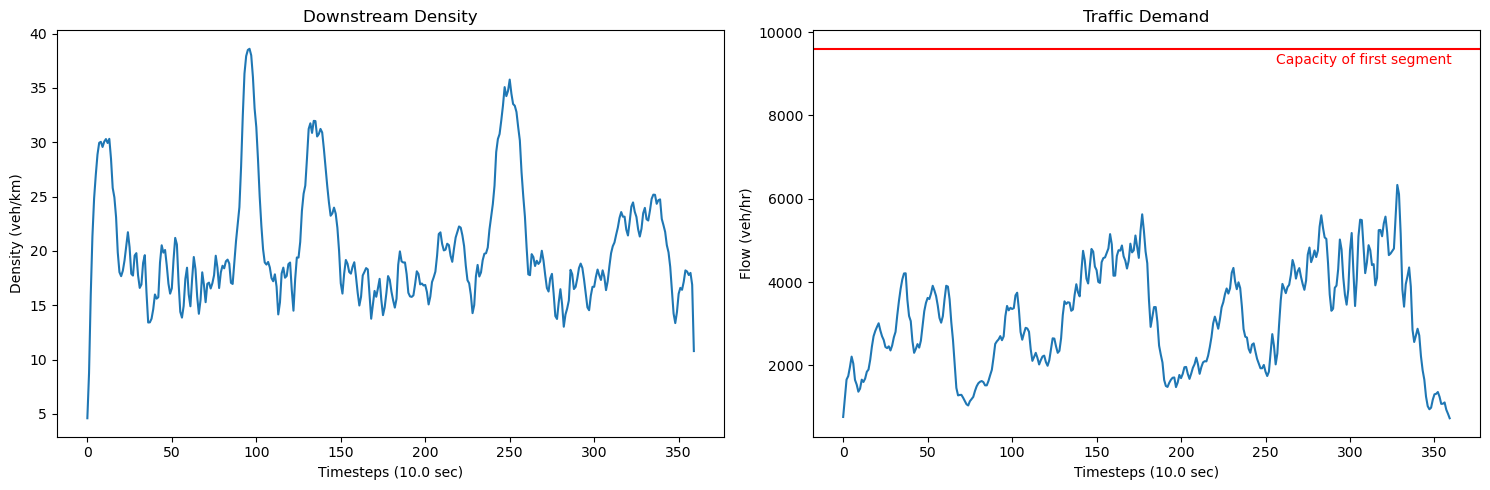

In [ ]:
density_data:   np.ndarray = np.clip(np.load(f'{data_path}/rho_hat.npy'), 1e-3, None) # time_steps x (n_segments+2)
flow_data:      np.ndarray = np.clip(np.load(f'{data_path}/q_hat.npy'), 1e-3, None) # time_steps x (n_segments+2)
velocity_data:  np.ndarray = flow_data/density_data
lane_counts = np.load(f'{cal_path}/num_lanes.npy').reshape(-1) if calibration_interval is None else np.load(f'{cal_path}/params_1/num_lanes.npy').reshape(-1)
lane_dict = {i: lane_count for i, lane_count in enumerate(lane_counts)}

time_steps, num_segments = density_data.shape
num_segments -= 2  # Subtract 2 for the boundary segments
total_distance = L * num_segments # km

true_density_initial  = density_data[start_time_step, 1:-1].reshape(-1) / lane_counts # (n_segments)
true_velocity_initial = velocity_data[start_time_step, 1:-1].reshape(-1) # (n_segments)

data_inflow: np.ndarray = smooth_inflow(flow_data[:, 0].reshape(-1), window_size=2) # (time_steps)
downstream_density: np.ndarray = smooth_inflow(density_data[:, -1].reshape(-1), window_size=2) / lane_dict[num_segments - 1] # (time_steps)

velocity_data = velocity_data[:, 1:-1] # remove boundary conditions (time_steps x n_segments)
flow_data     = flow_data[:, 1:-1] # remove boundary conditions (time_steps x n_segments)
density_data  = density_data[:, 1:-1] / lane_counts # remove boundary conditions (time_steps x n_segments)

print("time_step:\t\t", time_step * 3600, "seconds")
print("time_steps:\t\t", time_steps)
print("num_segments:\t\t", num_segments)
print("sim_time:\t\t", time_step * time_steps * 60, "minutes")
print("length of highway:\t", total_distance, "km")

p = Plotter(1, 2)
p[0] = {'title': 'Downstream Density', 'xlabel': f'Timesteps ({time_step*3600} sec)', 'ylabel': 'Density (veh/km)'}
p[0].plot(downstream_density)
p[1] = {'title': 'Traffic Demand', 'xlabel': f'Timesteps ({time_step*3600} sec)', 'ylabel': 'Flow (veh/hr)'}
p[1].plot(data_inflow)
p[1].axhline(2400 * lane_counts[0], c='red')
p[1].text(x=len(data_inflow), y=2400 * lane_counts[0]-100, s="Capacity of first segment", va="top", ha="right", color="red")
p.show()

### Load calibrated parameters

In [162]:
from param_loader import METANET_Params

subfolders = [
    f for f in os.listdir(cal_path)
    if os.path.isdir(cal_path / f) and f.startswith("params_")
]

if subfolders:
    print(f"Dynamic parameters detected: {len(subfolders)} subfolder(s) found")
    control_h = time_steps // len(subfolders)
    model_params = METANET_Params(path=data_path/calibration_id, control_h=control_h, num_timesteps=time_steps, num_segments=num_segments).get_params()
else:
    print("No dynamic parameter subfolders found — using static calibration parameters")
    model_params = METANET_Params(path=cal_path, num_timesteps=time_steps, num_segments=num_segments).get_params()

No dynamic parameter subfolders found — using static calibration parameters


## Simulations

### Simulation without Control

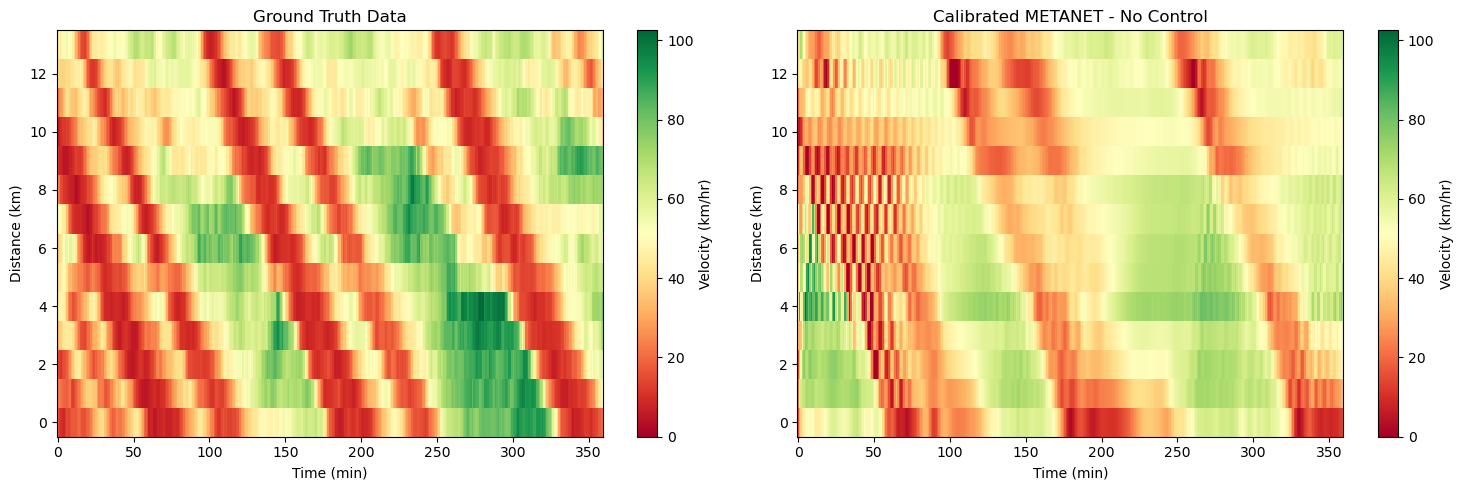

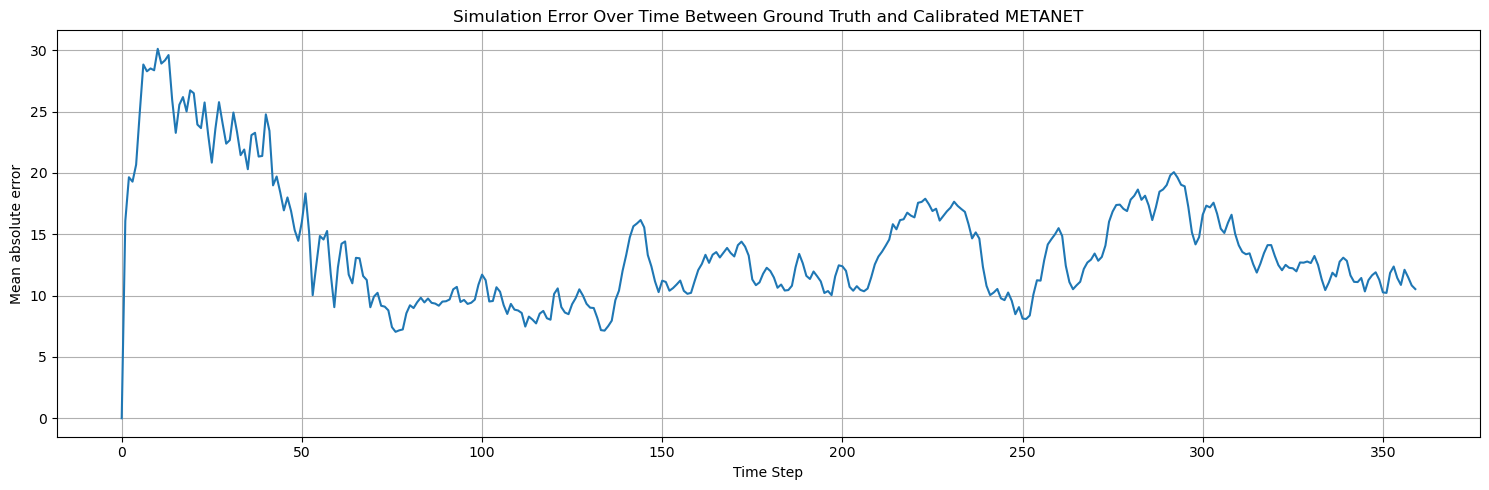

Ground Truth vs METANET
Velocity:	 (mape 58.06 %, rmse 17.68)
Density:	 (mape 33.85 %, rmse 9.1)
Flow:   	 (mape 52.89 %, rmse 1751.24)
Travel Time:	 562.15 veh-hr vs 549.26 veh-hr (mape 2.29 %)


In [270]:
const_vsl = np.array([np.full(num_segments, np.max(model_params['v_free'])) for _ in range(time_steps)])
init_state = (true_density_initial, true_velocity_initial, data_inflow[start_time_step], 0)

p_sim, v_sim, _, _ = run_metanet_sim_plottable(
                                T=time_step, # 10 sec
                                l=L, # 0.4 miles
                                init_traffic_state=init_state, # (n_segments, n_segments, time_steps, 1)
                                demand=data_inflow[start_time_step:], # time_steps
                                downstream_density=downstream_density[start_time_step:], # time_steps
                                params=model_params,
                                lanes=lane_dict,
                                vsl_speeds=None,
                                real_data=True
                              )

p_sim = p_sim[0:-1, :]
v_sim = v_sim[0:-1, :]

# Read in v_pred.npy from the path location
max_v = max(np.max(velocity_data), np.max(v_sim)).item()

p = Plotter(1, 2)
for i, mat in enumerate([velocity_data, v_sim]):
  p.fig.colorbar(mappable=p[i].imshow(mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v),
    ax=p[i], label='Velocity (km/hr)')
  p[i] = {'xlabel': 'Time (min)', 'ylabel': 'Distance (km)'}
  p[i].invert_yaxis()
p[0] = {'title': 'Ground Truth Data'}
p[1] = {'title': 'Calibrated METANET - No Control'}
p.show()

p = Plotter(1, 1, figsize=(15, 5))
p[0].plot(np.abs(velocity_data - v_sim).mean(axis=1))
p[0] = {'xlabel': 'Time Step', 'ylabel': 'Mean absolute error', 
        'title': 'Simulation Error Over Time Between Ground Truth and Calibrated METANET'}
p[0].grid()
p.show()

flow_sim = v_sim * p_sim * lane_counts

print("Ground Truth vs METANET")
def mape(y_true, y_pred): return np.mean(np.abs((y_true - y_pred) / y_true) * 100)
def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))
for qt, y, y_pred in [('Velocity', velocity_data, v_sim), ('Density', density_data, p_sim), ('Flow', flow_data, flow_sim)]:
  print(f"{qt+':':<8}\t (mape {round(mape(y, y_pred), 2)} %, rmse {round(rmse(y, y_pred), 2)})")

gt_tt, metanet_tt = (time_step * L * (np.sum(rhos * lane_counts[np.newaxis,:])) for rhos in [density_data, p_sim])
print(f"Travel Time:\t {gt_tt:.2f} veh-hr vs {metanet_tt:.2f} veh-hr (mape {(np.abs(gt_tt - metanet_tt) / gt_tt * 100):.2f} %)")

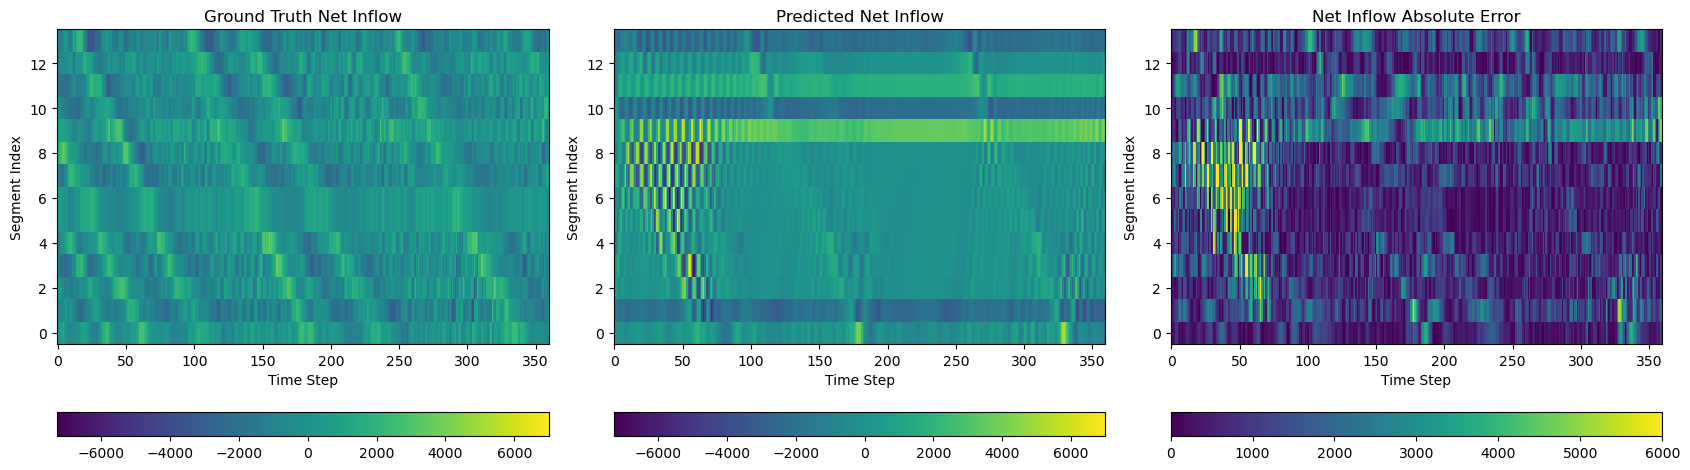

In [250]:
def get_velocity_heatmap(v_hat, v_pred, q_hat, q_pred, rho_hat, rho_pred):
    shortened_v_hat = v_hat
    shortened_rho_hat = rho_hat
    # Determine some set of 3 scalars for each of q, rho, v to make a unified map
    v_diff = np.abs(shortened_v_hat - v_pred)/shortened_v_hat
    rho_diff = np.abs(shortened_rho_hat - rho_pred)/shortened_rho_hat 
    diff = v_diff + rho_diff

    p = Plotter(1, 2)
    for i, (mat, cmap) in enumerate(zip([diff, shortened_v_hat], ["viridis", "RdYlGn"])):
        p.fig.colorbar(
            mappable=p[i].imshow(mat.T, cmap=cmap, aspect='auto', interpolation='none', 
                                 vmin=0 if i == 0 else None, vmax=1 if i == 0 else None),
            ax=p[i]
        )
        p[i] = {'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
        p[i].invert_yaxis()
    p[0] = {'title': 'Combined Normalized Difference Heatmap'}
    p[1] = {'title': 'Ground Truth Velocity Heatmap'}
    p.show()

# Calculate the error on the net_inflow
q_hat_inflow = np.hstack((data_inflow.reshape(-1, 1), flow_data))[:, :-1]
q_pred_inflow = np.hstack((data_inflow.reshape(-1, 1), flow_sim))[:, :-1]
net_inflow_hat = q_hat_inflow - flow_data
net_inflow_pred = q_pred_inflow - flow_sim
mape = np.abs(net_inflow_hat - net_inflow_pred)

netinflow_min = min(net_inflow_hat.min(), net_inflow_pred.min())
netinflow_max = max(net_inflow_hat.max(), net_inflow_pred.max())

p = Plotter(1, 3)
for i, mat in enumerate([net_inflow_hat, net_inflow_pred, mape]):
    p.fig.colorbar(
        mappable=p[i].imshow(mat.T, cmap='viridis', aspect='auto', interpolation='none', 
                            vmin=netinflow_min if i < 2 else None, vmax=netinflow_max if i < 2 else 6000),
        ax=p[i], orientation='horizontal'
    )
    p[i] = {'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
    p[i].invert_yaxis()
p[0] = {'title': 'Ground Truth Net Inflow'}
p[1] = {'title': 'Predicted Net Inflow'}
p[2] = {'title': 'Net Inflow Absolute Error'}
p.show()


### Simulation with constant VSL control

TTS (VSL=100): 748.73 veh-hr
TTS (VSL=150): 550.63 veh-hr


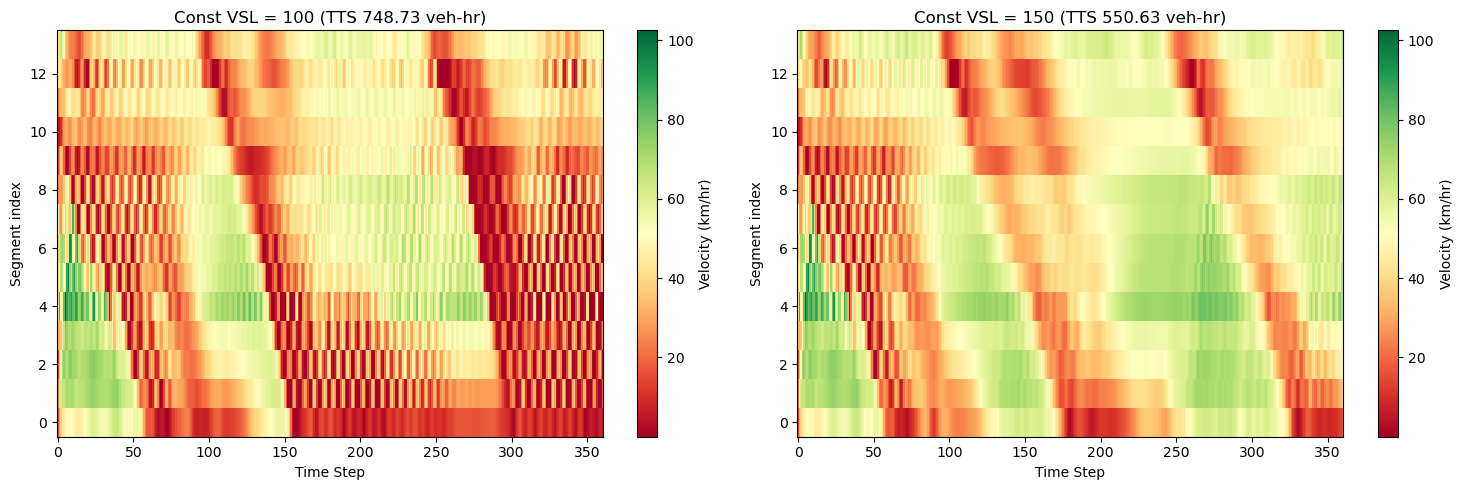

In [268]:
# simulate with constant VSL = 130 and VSL = 150, then plot side-by-side heatmaps
const_vsls = [100, 150]

# Run simulations (turn off internal plotting to avoid duplicates)
ps, vs, qs, ttss = zip(*(run_metanet_sim_plottable(time_step, L, init_state,
                                                   data_inflow[start_time:],
                                                   downstream_density[start_time:],
                                                   model_params,
                                                   lanes=lane_dict,
                                                   vsl_speeds=np.ones((time_steps, num_segments)) * vsl,
                                                   real_data=False) for vsl in const_vsls))
for vsl, tts in zip(const_vsls, ttss):
    print(f"TTS (VSL={vsl}): {tts:.2f} veh-hr")

# consistent color scale
vmin = min(np.min(velocity_data[:, 1:-1]), np.array(vs).min())
vmax = max(np.max(velocity_data[:, 1:-1]), np.array(vs).max())

p = Plotter(1, 2)
for i, (v_mat, sl, tts) in enumerate(zip(vs, const_vsls, ttss)):
  p.fig.colorbar(
      mappable=p[i].imshow(v_mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=vmin, vmax=vmax),
      ax=p[i], label='Velocity (km/hr)'
  )
  p[i] = {'title': f'Const VSL = {sl} (TTS {np.round(tts, 2)} veh-hr)', 'xlabel': 'Time Step', 'ylabel': 'Segment index'}
  p[i].invert_yaxis()
p.show()


### Simulation with Optimized Control

In [284]:
pred_horizon = 45  # in time steps
control_horizon = 5 # in time steps
hold_len = 1

pad_size = pred_horizon - control_horizon + 2
downstream_density_mpc = np.pad(downstream_density, (0, pad_size), mode="edge")
inflow_mpc = np.pad(data_inflow, (0, pad_size), mode="edge")

print(data_inflow.shape, '---padding-->', inflow_mpc.shape)

init_state = (true_density_initial, true_velocity_initial, data_inflow[start_time], 0)
for k, v in model_params.items():
    if isinstance(v, np.ndarray) and v.ndim == 2:
        print(k, v.shape, "sliced!" if v.shape[0] == time_steps else "NOT SLICED — passed through whole")
print('model params:', {k: v.shape for k, v in model_params.items()})

(360,) ---padding--> (402,)
model params: {'tau': (14,), 'K': (14,), 'eta_high': (14,), 'p_crit': (14,), 'v_free': (14,), 'a': (14,), 'q_capacity': (14,), 'r': (14,), 'beta': (14,), 'gamma': (14,)}


In [ ]:
import logging 
logging.getLogger('pyomo.core').setLevel(logging.ERROR)

# Optimize I-24 Scenario
import json
from mpc_metanet import mpc_find_vsl

# init_path = f'{results_path}/optimal_vsl_92.npy'
# init_vsl = np.load(init_path)
for speed_lb in SPEED_LBS:#[24, 27, 30]:
    vsl_opt_config = {
        "hold_length": hold_len,
        "control_changepoints": None,
        "safety_temporal": None,
        "safety_spatial": None,
        "speed_lb": speed_lb,
        "warmup_time": 0, 
        "control_zone": [i for i in range(2, num_segments)],
        "control_one_segment": None,
        "initialize_vsl": None,
        "init_fixed": None, #[speed_lb, 100, 120, 140, 150], #speed if speed > 0 else None,
        "tee": False,
        "pred_horizon": pred_horizon,
        "control_horizon": control_horizon
    }

    opt_horizon = time_steps + vsl_opt_config["pred_horizon"] - vsl_opt_config["control_horizon"]

    print(f"Starting optimization... ")
    optimal_vsl = mpc_find_vsl(opt_horizon, inflow_mpc[start_time:], downstream_density_mpc[start_time:], lane_dict,
                            T=time_step,l=L, num_segments=num_segments, init_state=init_state, params=model_params, verbose=True, v_fd_penalty=1e14, **vsl_opt_config)

    print(optimal_vsl.shape)

    if CONSTRAINT == "speed_lb": path_id = f"optimal_vsl_{speed_lb}"
    else: path_id = f"optimal_vsl"
    os.makedirs(results_path, exist_ok=True)
    if vsl_opt_config["initialize_vsl"] is not None:
        raise NotImplementedError("Loading from file is not implemented yet")
        # vsl_opt_config["initialize_vsl"] = f"loaded from file {init_path}"

    # WRITES
    np.save(f'{results_path}/{path_id}.npy', optimal_vsl)
    with open(f'{results_path}/{path_id}_config.json', "w") as file:
        json.dump(vsl_opt_config, file, indent=4)

Starting optimization... 
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 25
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 65
[MPC t=65] Attempt 'provided/shifted solution' failed: Solver did not converge (termination condition: maxIterations).

In [80]:
print(model_params['v_free'])

[ 87.10210005  83.42995873  71.50486178  70.          94.17244619
  70.          89.51853108  70.          70.          95.13600776
  70.          70.         117.46739304 149.99999998]


In [81]:
# # Print ramp info
# print("Ramp info:")
# for i in range(num_segments):
#     print(f"Segment {i}: lanes={lane_dict[i]}, on-ramp={model_params['r'][i] > 0.001}, off-ramp={model_params['beta'][i] > 0.001}")

## Plotting controlled traffic scenario

In [311]:
np.set_printoptions(suppress=True)

(p_baseline, v_baseline, _, tts_baseline), (p_opt, v_opt, queue, tts_opt) = \
                                (run_metanet_sim_plottable(time_step,
                                   L, 
                                   init_state, 
                                   data_inflow,
                                   downstream_density,
                                   model_params,
                                   lanes = lane_dict,
                                   vsl_speeds=vsl,
                                   real_data=False
                                  ) for vsl in [np.ones((time_steps, num_segments))*150, optimal_vsl])

print(f'{round(tts_baseline, 2)} veh-hr ---optimal---> {round(tts_opt, 2)} veh-hr')

assert np.allclose(queue, 0), "Queue is not zero, something went wrong with the optimization or simulation"

550.63 veh-hr ---optimal---> 383.1 veh-hr


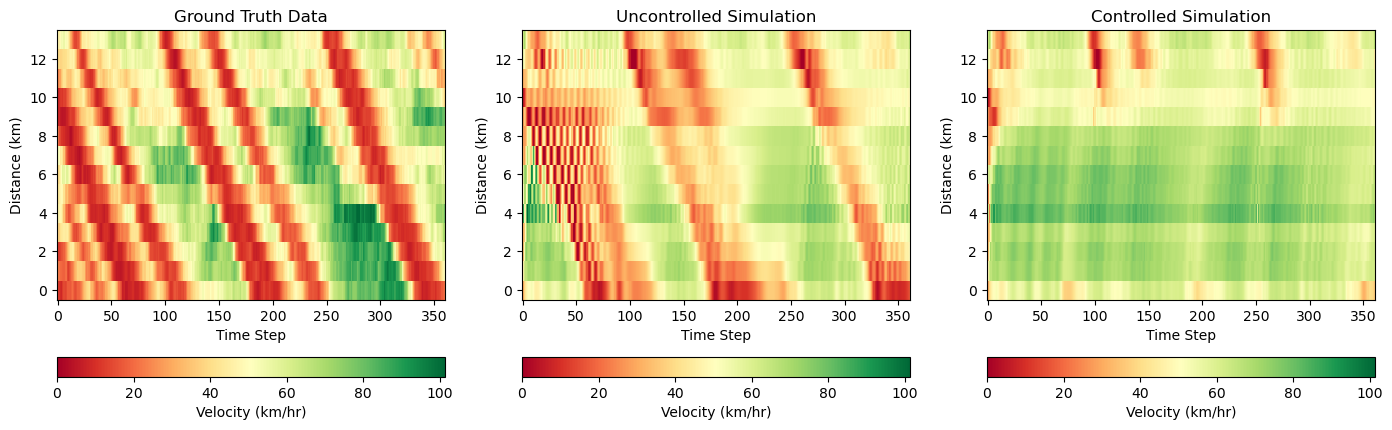

In [309]:
# Read in v_pred.npy from the path location
max_v = max(np.max(v_baseline), np.max(v_opt)).item()

p = Plotter(1, 3)
for i, mat in enumerate([velocity_data, v_baseline, v_opt]):
  p.fig.colorbar(
      mappable=p[i].imshow(mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v),
      ax=p[i], label='Velocity (km/hr)', orientation='horizontal' 
  )
  p[i] = {'xlabel': 'Time Step', 'ylabel': 'Distance (km)'}
  p[i].invert_yaxis()
p[0] = {'title': 'Ground Truth Data'}
p[1] = {'title': 'Uncontrolled Simulation'}
p[2] = {'title': 'Controlled Simulation'}
# plt.savefig("/Users/tristanchaang/MIT/UROP-Traffic/mpc-traffic-flow/figs/11_22_tsdiagram", dpi=150, bbox_inches='tight')

In [ ]:
from generate_demand_synthetic import get_ff_tts

ff_ttt = get_ff_tts(data_inflow, time_step, L, model_params['v_free'])
print(f"Total free flow travel time: {ff_ttt:.2f} veh-hrs")
delay  = tts_baseline - ff_ttt
opt_delay = tts_opt - ff_ttt
print(f"Controllable congestion: {(delay - opt_delay) / delay * 100:.2f}%")

Total free flow travel time: 214.24 veh-hrs
Controllable congestion: 49.80%


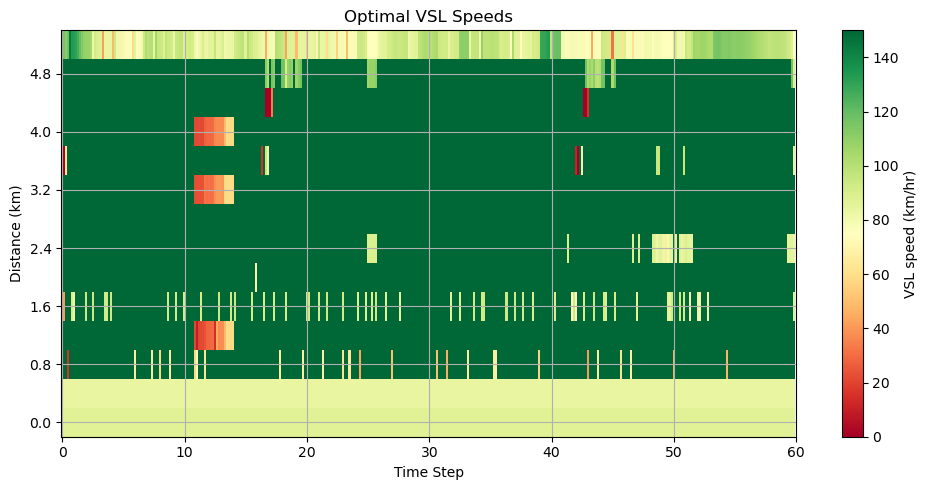

In [316]:
from plotting import plot_vsls
optimal_vsl: np.ndarray = np.load(f'{results_path}/{path_id}.npy')
v_free_extended = np.tile(model_params['v_free'], (optimal_vsl.shape[0], 1))
optimal_vsl = np.where(optimal_vsl > v_free_extended, 150, optimal_vsl)
plot_vsls(optimal_vsl, time_steps+1, num_segments, np.max(model_params['v_free']), T=time_step, l=L)

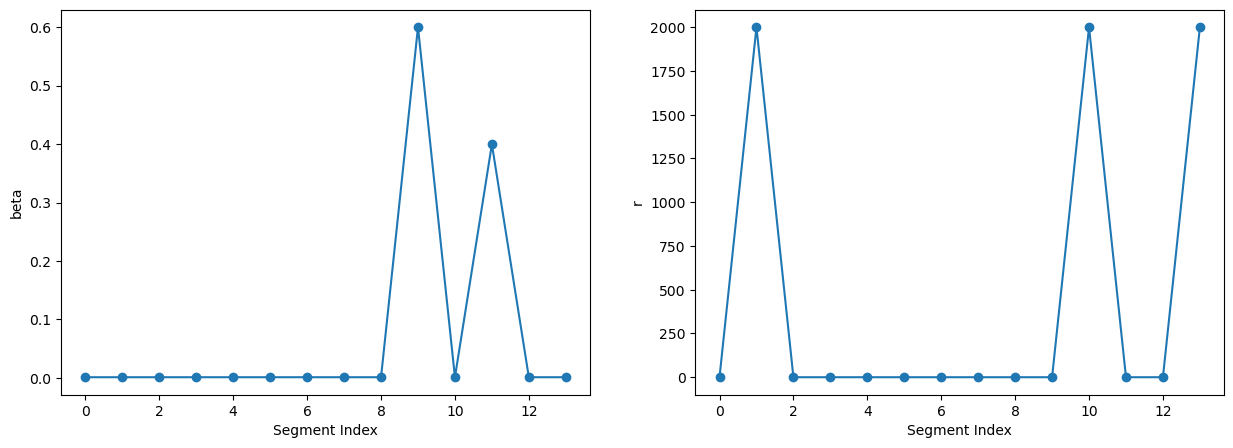

In [295]:
p = Plotter(1, 2)
for i, variable in enumerate(['beta', 'r']):
  p[i] = {'xlabel': 'Segment Index', 'ylabel': variable}
  p[i].plot(model_params[variable], marker='o')

min and max delay (ground truth): -0.10067403801637502 7.3622940475497
min and max pct decrease: 446.37662981232546 -27849072.00846189


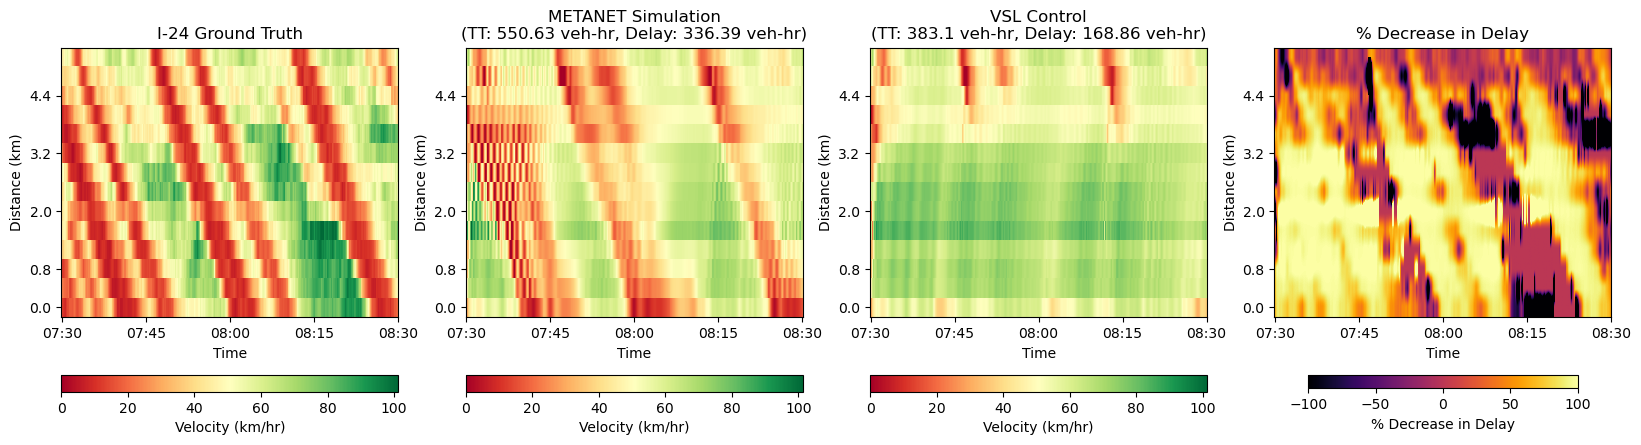

In [340]:
start_wallclock_time = 7.5 # 7

n_time = velocity_data[:, 1:-1].shape[0] +1
minutes = np.arange(n_time) * time_step * 60
tick_pos = np.linspace(0, n_time - 1, 5, dtype=int)

def to_wallclock(tick_minutes, start_hour):
    def format_time(minutes):
        hour, minute = divmod(int(start_hour * 60 + minutes), 60)
        return f"{hour % 24:02d}:{minute:02d}"

    return [format_time(m) for m in tick_minutes]

tick_labels = to_wallclock(minutes[tick_pos], start_wallclock_time)

# Compute y ticks in km — add this before the imshow calls
n_segments = velocity_data[:, 1:-1].shape[1]
ytick_pos = np.linspace(0, n_segments - 1, 5, dtype=int)
ytick_labels = [f"{i * 0.4:.1f}" for i in ytick_pos]  # 400m per segment → km

# pointwise delay
# --- Compute Delay ---
# free_flow_speed shape: (n_segments,) → reshape to (n_segments, 1) to broadcast over time
free_flow_speed_2d = np.array(model_params['v_free'])[:, np.newaxis]  # or .reshape(-1, 1)

delay_gt        = (0.4 / velocity_data.T - 0.4 / free_flow_speed_2d) * 60
delay_noctrl    = (0.4 / v_baseline[0:-1, :].T - 0.4 / free_flow_speed_2d) * 60
delay_ctrl      = (0.4 / v_opt[0:-1, :].T - 0.4 / free_flow_speed_2d) * 60

print('min and max delay (ground truth):', np.min(delay_gt), np.max(delay_gt))

pct_decrease = np.where(delay_gt > 0.01, (delay_gt - delay_ctrl) / delay_gt * 100, 0)
print('min and max pct decrease:', np.max(pct_decrease), np.min(pct_decrease))

p = Plotter(1, 4)
for i, mat in enumerate([velocity_data, v_baseline, v_opt]):
  p.fig.colorbar(
      mappable=p[i].imshow(mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v),
      ax=p[i], label='Velocity (km/hr)', orientation='horizontal'
  )
p.fig.colorbar(
    mappable=p[3].imshow(pct_decrease, cmap='inferno', aspect='auto', vmin=-100, vmax=100),
    ax=p[3], label='% Decrease in Delay', orientation='horizontal', location='bottom', pad=0.15, shrink=0.8, aspect=20
)
for i, ax in enumerate(p):
  p[i] = {'xlabel': 'Time', 'ylabel': 'Distance (km)', 'xticks': tick_pos, 'yticks': ytick_pos, 
          'xticklabels': tick_labels, 'yticklabels': ytick_labels}
  p[i].invert_yaxis()

p[0] = {'title': f'I-24 Ground Truth'}
p[1] = {'title': f'METANET Simulation\n(TT: {np.round(tts_baseline, 2)} veh-hr, Delay: {np.round(delay, 2)} veh-hr)'}
p[2] = {'title': f'VSL Control\n(TT: {np.round(tts_opt, 2)} veh-hr, Delay: {np.round(opt_delay, 2)} veh-hr)'}
p[3] = {'title': f'% Decrease in Delay'}

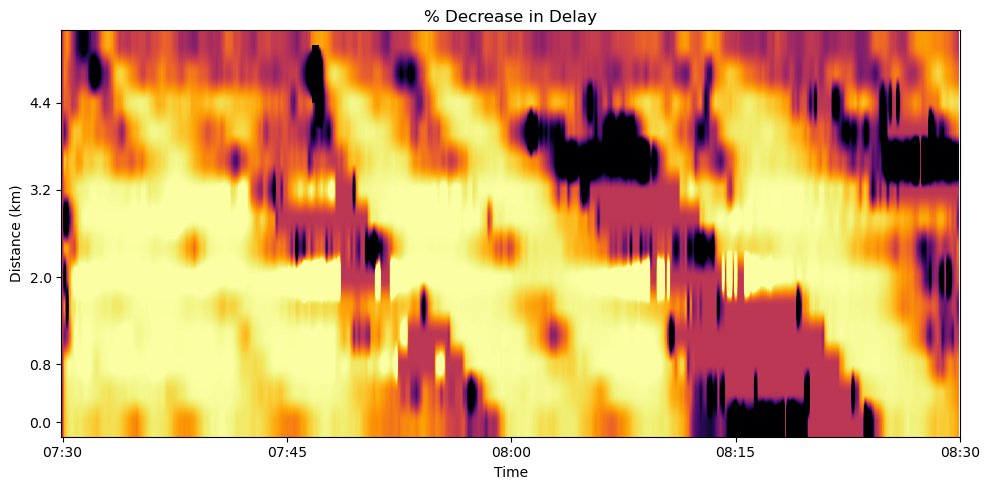

In [339]:
# Plot just the percent decrease in delay
p = Plotter(1, 1)

p[0].imshow(pct_decrease, cmap='inferno', aspect='auto', vmin=-100, vmax=100)
p[0].invert_yaxis()
p[0] = {'xlabel': 'Time', 'ylabel': 'Distance (km)', 'xticks': tick_pos, 'yticks': ytick_pos, 
          'xticklabels': tick_labels, 'yticklabels': ytick_labels, 'title': f'% Decrease in Delay'}
p.show()